In [ ]:
import pandas as pd

df = pd.read_csv("erosion_dataset.csv")

X = df[["slope", "ndvi", "elevation"]]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Identify rows with NaN in y_train
nan_indices_train = y_train.isna()

# Remove corresponding rows from X_train and y_train
X_train_cleaned = X_train[~nan_indices_train]
y_train_cleaned = y_train[~nan_indices_train]

rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train_cleaned, y_train_cleaned)

y_pred_rf = rf.predict(X_test)

In [ ]:
from xgboost import XGBRegressor

# Identify rows with NaN in y_train
nan_indices_train_xgb = y_train.isna()

# Remove corresponding rows from X_train and y_train
X_train_cleaned_xgb = X_train[~nan_indices_train_xgb]
y_train_cleaned_xgb = y_train[~nan_indices_train_xgb]

xgb = XGBRegressor(n_estimators=50)
xgb.fit(X_train_cleaned_xgb, y_train_cleaned_xgb)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Random Forest
rmse_rf = mean_squared_error(y_test, y_pred_rf)**0.5
r2_rf = r2_score(y_test, y_pred_rf)

# XGBoost
rmse_xgb = mean_squared_error(y_test, y_pred_xgb)**0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("Random Forest → RMSE:", rmse_rf, "R2:", r2_rf)
print("XGBoost → RMSE:", rmse_xgb, "R2:", r2_xgb)

Random Forest → RMSE: 0.0 R2: 1.0
XGBoost → RMSE: 0.03285751804848244 R2: 0.993832405968693


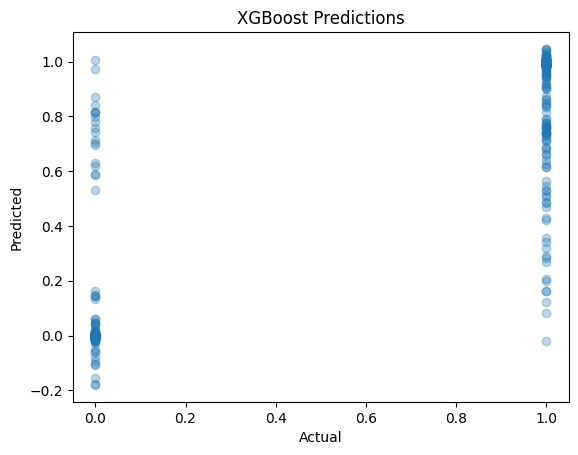

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred_class = (y_pred_xgb > 0.5).astype(int)
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17940
         1.0       1.00      1.00      1.00      5245

    accuracy                           1.00     23185
   macro avg       1.00      1.00      1.00     23185
weighted avg       1.00      1.00      1.00     23185

